# Water-Sensor Data Cleaning Pipeline

This notebook cleans the hourly water-sensor measurements and creates the dataset used by the clustering workflow.

## Main outputs

- `df_raw`: untouched copy of the imported dataframe.
- `df_clean`: cleaned observations plus audit and diagnostic columns.
- `df_model`: recommended complete-case dataset for clustering.
- `df_model_strict`: optional sensitivity dataset; **not** the recommended default.

## Cleaning principles

- Remove documented error codes and clearly invalid values.
- Consolidate duplicate sensor timestamps.
- Invalidate only the affected measurement channel where possible.
- Remove persistent near-zero oxygen failures.
- Remove brief conductivity collapses and isolated turbidity spikes using hourly time structure.
- Keep broader anomaly rules as diagnostics rather than automatic deletion.
- Do not interpolate values.

> Confirm the true conductivity unit before publishing values. The column name contains `mS_cm`, while values near 50,000 may indicate a different stored unit.

## 1. Imports and data input

The notebook uses an existing dataframe named `df`. The optional local CSV path is used only when `df` has not already been created.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
# Optional local fallback. Edit the path when running on another computer.
DATA_PATH = Path(r"C:\Users\User\Desktop\water\data\water_stats.csv")

if "df" not in globals():
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            "No dataframe named 'df' exists and DATA_PATH was not found. "
            "Import the dataset as df or edit DATA_PATH."
        )

    df = pd.read_csv(DATA_PATH)

print(f"Loaded dataframe shape: {df.shape}")

Loaded dataframe shape: (34146, 19)


## 2. Configuration

All column names, known error codes, physical screening limits, and rule parameters are defined here so that the cleaning choices are easy to review.

In [3]:
SENSOR_COL = "sensor_id"
TIME_COL = "date_insert"

TEMPERATURE_COL = "wtempV_°C"
CONDUCTIVITY_COL = "conductivity_of_solution_ mS_cm"
ORP_COL = "oxidation_reduction_potential_ mV"
OXYGEN_COL = "oxygen_saturation_%"
TURBIDITY_COL = "turbidity_NTU"

MODEL_FEATURES = [
    CONDUCTIVITY_COL,
    ORP_COL,
    OXYGEN_COL,
    TURBIDITY_COL,
]

AUXILIARY_FEATURES = [TEMPERATURE_COL]
CLEANED_FEATURES = AUXILIARY_FEATURES + MODEL_FEATURES

REGIONS = {
    976: "Ακταίο",
    977: "Ψαθόπυργος",
    978: "Αραχωβίτικα",
    979: "Άγιος Βασίλης",
    980: "Ρίο",
    981: "Καστελλόκαμπος",
    982: "Δάφνες",
    983: "Πλάζ",
    984: "Ροιτικά",
}

# Confirmed device error codes.
SENTINEL_VALUES = [
    9998.01,
    9999.01,
    9999.0,
    -999.0,
    9998.04,
    9991.04,
]

# Conservative technical limits, not environmental-quality thresholds.
HARD_LIMITS = {
    TEMPERATURE_COL: (0.0, 45.0),
    CONDUCTIVITY_COL: (0.0, 100_000.0),
    ORP_COL: (-1_000.0, 1_000.0),
    OXYGEN_COL: (0.0, 200.0),
    TURBIDITY_COL: (0.0, 1_000.0),
}

# Persistent near-zero oxygen rule.
OXYGEN_FAILURE_THRESHOLD = 1.0
MIN_LOW_OXYGEN_READINGS = 12
MIN_LOW_OXYGEN_DURATION = pd.Timedelta("11h")
OXYGEN_MAX_ALLOWED_GAP = pd.Timedelta("2h")

# Short conductivity drop-and-recovery rule.
CONDUCTIVITY_DROP_RATIO = 0.35
CONDUCTIVITY_RECOVERY_RATIO = 0.75
MIN_CONDUCTIVITY_BASELINE = 20_000
MIN_CONDUCTIVITY_DROP = 10_000
MAX_TRANSIENT_READINGS = 3
CONDUCTIVITY_MAX_SEQUENCE_GAP = pd.Timedelta("2h")
MAX_RECOVERY_GAP = pd.Timedelta("4h")

# Additional short conductivity-collapse rule.
CONDUCTIVITY_LOCAL_RATIO = 0.45
MIN_LOCAL_CONDUCTIVITY_DROP = 10_000
MAX_LOCAL_COLLAPSE_READINGS = 4

# Isolated turbidity-spike rule.
MIN_TURBIDITY_SPIKE = 150.0
TURBIDITY_SPIKE_RATIO = 4.0
MAX_TURBIDITY_SPIKE_READINGS = 2
TURBIDITY_MAX_SEQUENCE_GAP = pd.Timedelta("2h")

# Diagnostic-only rolling anomaly flags.
ROLLING_WINDOW = "48h"
ROLLING_MIN_OBSERVATIONS = 8
ROBUST_Z_THRESHOLD = 8.0

MIN_ABSOLUTE_DEVIATION = {
    TEMPERATURE_COL: 2.0,
    CONDUCTIVITY_COL: 5_000.0,
    ORP_COL: 150.0,
    OXYGEN_COL: 30.0,
    TURBIDITY_COL: 100.0,
}

# Diagnostic-only oxygen flags.
OXYGEN_LOW_24H_THRESHOLD = 10.0
OXYGEN_NOISY_24H_STD_THRESHOLD = 25.0
OXYGEN_DRIFT_LEVEL_THRESHOLD = 55.0
OXYGEN_DRIFT_CHANGE_THRESHOLD = -2.0

PLOT_GAP_THRESHOLD = pd.Timedelta("24h")

## 3. Validate, standardize, and preserve the data

This stage validates the required columns, preserves the original dataframe, converts timestamps and numeric measurements, adds location names when needed, and sorts every sensor chronologically.

In [4]:
required_columns = [SENSOR_COL, TIME_COL] + CLEANED_FEATURES
missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"The dataframe is missing required columns: {missing_columns}"
    )

df_raw = df.copy(deep=True)
df_clean = df.copy(deep=True)

df_clean[TIME_COL] = pd.to_datetime(
    df_clean[TIME_COL],
    errors="coerce",
)

for column in CLEANED_FEATURES:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce",
    )

invalid_timestamp_mask = df_clean[TIME_COL].isna()
invalid_timestamp_rows = int(invalid_timestamp_mask.sum())

if invalid_timestamp_rows:
    df_clean = df_clean.loc[~invalid_timestamp_mask].copy()

if "location" not in df_clean.columns:
    df_clean["location"] = df_clean[SENSOR_COL].map(REGIONS)

df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["_source_row_id"] = np.arange(len(df_clean))

print(f"Original rows: {len(df_raw):,}")
print(f"Rows after timestamp validation: {len(df_clean):,}")
print(f"Sensors: {df_clean[SENSOR_COL].nunique()}")
print(f"Invalid timestamps removed: {invalid_timestamp_rows:,}")

Original rows: 34,146
Rows after timestamp validation: 34,146
Sensors: 9
Invalid timestamps removed: 0


## 4. Remove exact duplicates and consolidate repeated timestamps

Exact duplicate rows are removed. When a sensor has multiple different records at the same timestamp, numeric values are combined with the median and non-numeric metadata uses the first available value.

In [5]:
exact_duplicate_mask = df_clean.duplicated(keep="first")
exact_duplicates_removed = int(exact_duplicate_mask.sum())
df_clean = df_clean.loc[~exact_duplicate_mask].copy()

duplicate_timestamp_mask = df_clean.duplicated(
    subset=[SENSOR_COL, TIME_COL],
    keep=False,
)

duplicate_timestamp_rows = int(duplicate_timestamp_mask.sum())
duplicate_timestamp_groups = int(
    df_clean.loc[
        duplicate_timestamp_mask,
        [SENSOR_COL, TIME_COL],
    ]
    .drop_duplicates()
    .shape[0]
)

numeric_columns = df_clean.select_dtypes(
    include=[np.number]
).columns.tolist()

numeric_columns = [
    column
    for column in numeric_columns
    if column not in [SENSOR_COL, "_source_row_id"]
]

non_numeric_columns = [
    column
    for column in df_clean.columns
    if column not in numeric_columns + [SENSOR_COL, TIME_COL]
]

aggregation_rules = {
    column: "median"
    for column in numeric_columns
}
aggregation_rules.update({
    column: "first"
    for column in non_numeric_columns
})

df_clean = (
    df_clean
    .groupby(
        [SENSOR_COL, TIME_COL],
        as_index=False,
        sort=False,
    )
    .agg(aggregation_rules)
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["_row_id"] = np.arange(len(df_clean))

print(f"Exact duplicate rows removed: {exact_duplicates_removed:,}")
print(
    "Duplicate sensor-timestamp groups consolidated:",
    f"{duplicate_timestamp_groups:,}",
)
print(f"Rows involved in duplicate timestamps: {duplicate_timestamp_rows:,}")
print(f"Rows after duplicate handling: {len(df_clean):,}")

Exact duplicate rows removed: 0
Duplicate sensor-timestamp groups consolidated: 0
Rows involved in duplicate timestamps: 0
Rows after duplicate handling: 34,146


## 5. Deterministic value cleaning

These rules remove confirmed device codes and values outside the configured technical limits. Every invalidation is recorded in an audit flag.

In [6]:
# Replace known sentinel values.
sentinel_audit_records = []

for column in CLEANED_FEATURES:
    original_values = df_clean[column].copy()
    sentinel_mask = pd.Series(False, index=df_clean.index)

    for sentinel in SENTINEL_VALUES:
        sentinel_mask |= np.isclose(
            original_values,
            sentinel,
            rtol=0.0,
            atol=1e-6,
            equal_nan=False,
        )

    df_clean[f"{column}__sentinel_invalid"] = sentinel_mask
    df_clean.loc[sentinel_mask, column] = np.nan

    sentinel_audit_records.append({
        "feature": column,
        "sentinel_values_removed": int(sentinel_mask.sum()),
    })

sentinel_audit = pd.DataFrame(sentinel_audit_records)

# Apply hard limits.
hard_limit_audit_records = []

for column, (lower_limit, upper_limit) in HARD_LIMITS.items():
    invalid_mask = (
        df_clean[column].notna()
        & (
            (df_clean[column] < lower_limit)
            | (df_clean[column] > upper_limit)
        )
    )

    df_clean[f"{column}__hard_limit_invalid"] = invalid_mask
    df_clean.loc[invalid_mask, column] = np.nan

    hard_limit_audit_records.append({
        "feature": column,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "hard_limit_values_removed": int(invalid_mask.sum()),
    })

hard_limit_audit = pd.DataFrame(hard_limit_audit_records)

print("Sentinel-code audit")
display(sentinel_audit)

print("Hard-limit audit")
display(hard_limit_audit)

Sentinel-code audit


,feature,sentinel_values_removed
0,wtempV_°C,0
1,conductivity_of_solution_ mS_cm,501
2,oxidation_reduction_potential_ mV,0
3,oxygen_saturation_%,114
4,turbidity_NTU,0


Hard-limit audit


,feature,lower_limit,upper_limit,hard_limit_values_removed
0,wtempV_°C,0.0,45.0,0
1,conductivity_of_solution_ mS_cm,0.0,100000.0,7
2,oxidation_reduction_potential_ mV,-1000.0,1000.0,3
3,oxygen_saturation_%,0.0,200.0,759
4,turbidity_NTU,0.0,1000.0,1360


## 6. Feature-specific failure and glitch cleaning

These rules use the hourly sequence of each sensor. They invalidate only the affected feature; the other measurements remain available in `df_clean`.

### 6.1 Persistent near-zero oxygen periods

Oxygen below 1% is invalidated only when it persists for at least 12 readings over approximately 11 hours, with no gap longer than 2 hours.

In [7]:
def remove_persistent_near_zero_oxygen(
    data: pd.DataFrame,
) -> pd.DataFrame:
    data = (
        data
        .sort_values([SENSOR_COL, TIME_COL])
        .reset_index(drop=True)
        .copy()
    )

    data["oxygen_saturation_original"] = data[OXYGEN_COL]

    data["oxygen_below_1_flag"] = (
        data[OXYGEN_COL].notna()
        & (data[OXYGEN_COL] < OXYGEN_FAILURE_THRESHOLD)
    )

    oxygen_time_gap = (
        data
        .groupby(SENSOR_COL)[TIME_COL]
        .diff()
    )

    previous_was_low = (
        data
        .groupby(SENSOR_COL)["oxygen_below_1_flag"]
        .shift(fill_value=False)
    )

    new_low_sequence = (
        data["oxygen_below_1_flag"]
        & (
            ~previous_was_low
            | oxygen_time_gap.gt(OXYGEN_MAX_ALLOWED_GAP)
        )
    )

    data["oxygen_low_sequence_id"] = (
        new_low_sequence
        .groupby(data[SENSOR_COL])
        .cumsum()
        .where(data["oxygen_below_1_flag"])
    )

    sequence_groups = [
        SENSOR_COL,
        "oxygen_low_sequence_id",
    ]

    data["oxygen_low_sequence_readings"] = (
        data
        .groupby(sequence_groups)[OXYGEN_COL]
        .transform("size")
        .where(data["oxygen_below_1_flag"])
    )

    sequence_start = (
        data
        .groupby(sequence_groups)[TIME_COL]
        .transform("min")
    )

    sequence_end = (
        data
        .groupby(sequence_groups)[TIME_COL]
        .transform("max")
    )

    data["oxygen_low_sequence_duration"] = (
        sequence_end - sequence_start
    ).where(data["oxygen_below_1_flag"])

    data["oxygen_persistent_near_zero"] = (
        data["oxygen_below_1_flag"]
        & (
            data["oxygen_low_sequence_readings"]
            >= MIN_LOW_OXYGEN_READINGS
        )
        & (
            data["oxygen_low_sequence_duration"]
            >= MIN_LOW_OXYGEN_DURATION
        )
    )

    data.loc[
        data["oxygen_persistent_near_zero"],
        OXYGEN_COL,
    ] = np.nan

    return data


df_clean = remove_persistent_near_zero_oxygen(df_clean)

print(
    "Individual oxygen readings below 1%:",
    int(df_clean["oxygen_below_1_flag"].sum()),
)
print(
    "Readings inside persistent near-zero periods:",
    int(df_clean["oxygen_persistent_near_zero"].sum()),
)

Individual oxygen readings below 1%: 11062
Readings inside persistent near-zero periods: 9850


In [8]:
oxygen_failure_intervals = (
    df_clean.loc[
        df_clean["oxygen_persistent_near_zero"]
    ]
    .groupby(
        [SENSOR_COL, "oxygen_low_sequence_id"],
        as_index=False,
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=("oxygen_saturation_original", "size"),
        minimum_oxygen=("oxygen_saturation_original", "min"),
        maximum_oxygen=("oxygen_saturation_original", "max"),
    )
)

oxygen_failure_intervals["duration_hours"] = (
    oxygen_failure_intervals["end_time"]
    - oxygen_failure_intervals["start_time"]
).dt.total_seconds() / 3600

display(oxygen_failure_intervals)

,sensor_id,oxygen_low_sequence_id,start_time,end_time,readings,minimum_oxygen,maximum_oxygen,duration_hours
0,976,20.0,2025-09-08 12:00:00,2025-09-10 09:00:00,46,0.0,0.0,45.0
1,976,21.0,2025-09-15 09:00:00,2025-09-25 15:00:00,247,0.0,0.0,246.0
2,976,22.0,2025-09-25 23:00:00,2025-10-02 13:00:00,159,0.0,0.0,158.0
3,976,26.0,2025-10-11 12:00:00,2025-10-13 09:00:00,46,0.0,0.0,45.0
4,976,37.0,2025-11-03 11:00:00,2025-11-03 22:00:00,12,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...
61,984,75.0,2025-12-22 07:00:00,2025-12-23 00:00:00,18,0.0,0.0,17.0
62,984,77.0,2025-12-23 17:00:00,2025-12-26 14:00:00,70,0.0,0.0,69.0
63,984,78.0,2025-12-26 16:00:00,2025-12-28 11:00:00,44,0.0,0.0,43.0
64,984,91.0,2025-12-30 15:00:00,2026-01-01 14:00:00,48,0.0,0.0,47.0


### 6.2 Conductivity glitches

Two conservative rules are used:

1. A brief collapse relative to the preceding 24-hour median that quickly recovers.
2. A remaining short collapse relative to a centered 24-hour median.

Longer conductivity changes are retained.

In [9]:
def detect_transient_conductivity_drops(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    baseline = (
        indexed[CONDUCTIVITY_COL]
        .rolling("24h", min_periods=12)
        .median()
        .shift(1)
    )

    sensor_df["conductivity_baseline_24h"] = baseline.to_numpy()

    conductivity_drop = (
        sensor_df["conductivity_baseline_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate_drop = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df["conductivity_baseline_24h"].notna()
        & (
            sensor_df["conductivity_baseline_24h"]
            >= MIN_CONDUCTIVITY_BASELINE
        )
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_DROP_RATIO
                * sensor_df["conductivity_baseline_24h"]
            )
        )
        & (conductivity_drop >= MIN_CONDUCTIVITY_DROP)
    )

    sensor_df["conductivity_drop_candidate"] = candidate_drop

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate_drop.shift(
        fill_value=False
    )

    new_sequence = (
        candidate_drop
        & (
            ~previous_was_candidate
            | time_gap.gt(CONDUCTIVITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate_drop)

    sensor_df["conductivity_drop_sequence_id"] = sequence_id
    sensor_df["conductivity_transient_glitch"] = False

    for current_sequence_id in sequence_id.dropna().unique():
        sequence_positions = np.flatnonzero(
            sequence_id.eq(current_sequence_id).to_numpy()
        )

        if len(sequence_positions) > MAX_TRANSIENT_READINGS:
            continue

        first_position = sequence_positions[0]
        last_position = sequence_positions[-1]
        previous_position = first_position - 1
        next_position = last_position + 1

        if (
            previous_position < 0
            or next_position >= len(sensor_df)
        ):
            continue

        sequence_start = sensor_df.iloc[first_position][TIME_COL]
        sequence_end = sensor_df.iloc[last_position][TIME_COL]
        previous_time = sensor_df.iloc[previous_position][TIME_COL]
        next_time = sensor_df.iloc[next_position][TIME_COL]

        if (
            sequence_start - previous_time
            > CONDUCTIVITY_MAX_SEQUENCE_GAP
        ):
            continue

        if next_time - sequence_end > MAX_RECOVERY_GAP:
            continue

        baseline_at_start = sensor_df.iloc[
            first_position
        ]["conductivity_baseline_24h"]

        previous_value = sensor_df.iloc[
            previous_position
        ][CONDUCTIVITY_COL]

        next_value = sensor_df.iloc[
            next_position
        ][CONDUCTIVITY_COL]

        if (
            pd.isna(baseline_at_start)
            or pd.isna(previous_value)
            or pd.isna(next_value)
        ):
            continue

        previous_is_normal = (
            previous_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        next_is_recovered = (
            next_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        if previous_is_normal and next_is_recovered:
            sensor_df.iloc[
                sequence_positions,
                sensor_df.columns.get_loc(
                    "conductivity_transient_glitch"
                ),
            ] = True

    return sensor_df


def detect_local_conductivity_collapses(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12,
        )
        .median()
    )

    sensor_df["conductivity_local_median_24h"] = (
        local_median.to_numpy()
    )

    absolute_drop = (
        sensor_df["conductivity_local_median_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df["conductivity_local_median_24h"].notna()
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_LOCAL_RATIO
                * sensor_df["conductivity_local_median_24h"]
            )
        )
        & (absolute_drop >= MIN_LOCAL_CONDUCTIVITY_DROP)
    )

    sensor_df["conductivity_local_collapse_candidate"] = candidate

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(CONDUCTIVITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate)

    sensor_df["conductivity_local_collapse_sequence_id"] = (
        sequence_id
    )

    sequence_size = (
        sensor_df
        .groupby(
            "conductivity_local_collapse_sequence_id"
        )[CONDUCTIVITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df["conductivity_local_collapse_readings"] = (
        sequence_size
    )

    sensor_df["conductivity_local_collapse"] = (
        candidate
        & (sequence_size <= MAX_LOCAL_COLLAPSE_READINGS)
    )

    return sensor_df

In [10]:
df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["conductivity_original"] = df_clean[CONDUCTIVITY_COL]

df_clean = (
    df_clean
    .groupby(SENSOR_COL, group_keys=False)
    .apply(detect_transient_conductivity_drops)
    .reset_index(drop=True)
)

df_clean.loc[
    df_clean["conductivity_transient_glitch"],
    CONDUCTIVITY_COL,
] = np.nan

df_clean["conductivity_before_local_cleaning"] = (
    df_clean[CONDUCTIVITY_COL]
)

df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .groupby(SENSOR_COL, group_keys=False)
    .apply(detect_local_conductivity_collapses)
    .reset_index(drop=True)
)

df_clean.loc[
    df_clean["conductivity_local_collapse"],
    CONDUCTIVITY_COL,
] = np.nan

print(
    "Transient conductivity glitches:",
    int(df_clean["conductivity_transient_glitch"].sum()),
)
print(
    "Additional short conductivity collapses:",
    int(df_clean["conductivity_local_collapse"].sum()),
)

Transient conductivity glitches: 64
Additional short conductivity collapses: 75


C:\Users\User\AppData\Local\Temp\ipykernel_17728\3922566727.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detect_transient_conductivity_drops)
C:\Users\User\AppData\Local\Temp\ipykernel_17728\3922566727.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detect_local_conductivity_collapses)


In [11]:
conductivity_glitch_intervals = (
    df_clean.loc[
        df_clean["conductivity_transient_glitch"]
    ]
    .groupby(
        [SENSOR_COL, "conductivity_drop_sequence_id"],
        as_index=False,
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=("conductivity_original", "size"),
        baseline_conductivity=(
            "conductivity_baseline_24h",
            "median",
        ),
        minimum_conductivity=(
            "conductivity_original",
            "min",
        ),
        maximum_conductivity=(
            "conductivity_original",
            "max",
        ),
    )
)

conductivity_glitch_intervals["duration_hours"] = (
    conductivity_glitch_intervals["end_time"]
    - conductivity_glitch_intervals["start_time"]
).dt.total_seconds() / 3600

conductivity_glitch_intervals["percentage_drop"] = (
    100
    * (
        conductivity_glitch_intervals["baseline_conductivity"]
        - conductivity_glitch_intervals["minimum_conductivity"]
    )
    / conductivity_glitch_intervals["baseline_conductivity"]
)

conductivity_local_collapse_intervals = (
    df_clean.loc[
        df_clean["conductivity_local_collapse"]
    ]
    .groupby(
        [
            SENSOR_COL,
            "conductivity_local_collapse_sequence_id",
        ],
        as_index=False,
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=(
            "conductivity_before_local_cleaning",
            "size",
        ),
        local_median=(
            "conductivity_local_median_24h",
            "median",
        ),
        minimum_conductivity=(
            "conductivity_before_local_cleaning",
            "min",
        ),
        maximum_conductivity=(
            "conductivity_before_local_cleaning",
            "max",
        ),
    )
)

conductivity_local_collapse_intervals[
    "percentage_below_local_median"
] = (
    100
    * (
        conductivity_local_collapse_intervals["local_median"]
        - conductivity_local_collapse_intervals[
            "minimum_conductivity"
        ]
    )
    / conductivity_local_collapse_intervals["local_median"]
)

print("Short drop-and-recovery intervals")
display(
    conductivity_glitch_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

print("Additional local-collapse intervals")
display(
    conductivity_local_collapse_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

Short drop-and-recovery intervals


,sensor_id,conductivity_drop_sequence_id,start_time,end_time,readings,baseline_conductivity,minimum_conductivity,maximum_conductivity,duration_hours,percentage_drop
0,976,2.0,2025-09-22 01:00:00,2025-09-22 01:00:00,1,56200.47,7542.16,7542.16,0.0,86.58
1,976,4.0,2025-12-03 10:00:00,2025-12-03 12:00:00,3,56928.38,1335.11,1335.11,2.0,97.65
2,977,1.0,2025-09-21 23:00:00,2025-09-21 23:00:00,1,59334.79,1748.49,1748.49,0.0,97.05
3,977,2.0,2025-09-24 11:00:00,2025-09-24 11:00:00,1,59260.94,1768.30,1768.30,0.0,97.02
4,977,3.0,2026-01-18 10:00:00,2026-01-18 10:00:00,1,48125.66,350.11,350.11,0.0,99.27
5,977,4.0,2026-01-19 10:00:00,2026-01-19 10:00:00,1,48181.08,2272.02,2272.02,0.0,95.28
6,977,5.0,2026-01-20 00:00:00,2026-01-20 00:00:00,1,48123.95,538.05,538.05,0.0,98.88
7,977,7.0,2026-01-21 05:00:00,2026-01-21 05:00:00,1,41832.32,993.92,993.92,0.0,97.62
8,977,8.0,2026-01-21 07:00:00,2026-01-21 09:00:00,3,40023.63,2628.64,5537.29,2.0,93.43
9,977,10.0,2026-01-25 22:00:00,2026-01-25 22:00:00,1,48254.04,258.93,258.93,0.0,99.46


Additional local-collapse intervals


,sensor_id,conductivity_local_collapse_sequence_id,start_time,end_time,readings,local_median,minimum_conductivity,maximum_conductivity,percentage_below_local_median
0,976,1.0,2025-09-20 23:00:00,2025-09-20 23:00:00,1,56167.10,14801.00,14801.00,73.65
1,977,1.0,2026-01-20 20:00:00,2026-01-20 20:00:00,1,40129.80,16739.64,16739.64,58.29
2,977,3.0,2026-01-26 01:00:00,2026-01-26 04:00:00,4,47488.36,650.06,8170.19,98.63
3,980,1.0,2025-09-21 11:00:00,2025-09-21 12:00:00,2,34831.86,6060.15,7037.00,82.60
4,982,1.0,2025-07-04 09:00:00,2025-07-04 09:00:00,1,38525.95,16524.16,16524.16,57.11
5,982,2.0,2025-07-04 19:00:00,2025-07-04 19:00:00,1,34853.55,12635.67,12635.67,63.75
6,982,4.0,2025-07-05 20:00:00,2025-07-05 20:00:00,1,55517.75,14181.13,14181.13,74.46
7,982,5.0,2025-07-05 22:00:00,2025-07-05 23:00:00,2,54553.12,15024.25,15819.47,72.46
8,982,8.0,2025-07-08 22:00:00,2025-07-09 01:00:00,4,51890.28,14639.71,22183.70,71.79
9,982,9.0,2025-07-10 09:00:00,2025-07-10 09:00:00,1,31832.18,14309.77,14309.77,55.05


### Targeted conductivity cleanup for sensors 982 and 984

Short conductivity collapses are removed for sensors 982 and 984 when they
fall substantially below the surrounding 24-hour median. Longer low-conductivity
periods remain available because they may represent genuine regime changes.

In [12]:
# ------------------------------------------------------------
# Targeted conductivity cleanup for sensors 982 and 984
# ------------------------------------------------------------

TARGET_CONDUCTIVITY_SENSORS = [982, 984]

TARGET_CONDUCTIVITY_RATIO = 0.70
TARGET_MIN_ABSOLUTE_DROP = 8_000

# Remove only short sequences.
TARGET_MAX_COLLAPSE_READINGS = 6
TARGET_MAX_SEQUENCE_GAP = pd.Timedelta("2h")


def detect_targeted_conductivity_collapses(sensor_df):
    sensor_df = (
        sensor_df
        .sort_values(TIME_COL)
        .copy()
    )

    sensor_id = sensor_df[SENSOR_COL].iloc[0]

    sensor_df[
        "targeted_conductivity_local_median"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_candidate"
    ] = False

    sensor_df[
        "targeted_conductivity_sequence_id"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_sequence_size"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_collapse"
    ] = False

    if sensor_id not in TARGET_CONDUCTIVITY_SENSORS:
        return sensor_df

    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12
        )
        .median()
    )

    sensor_df[
        "targeted_conductivity_local_median"
    ] = local_median.to_numpy()

    absolute_drop = (
        sensor_df[
            "targeted_conductivity_local_median"
        ]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df[
            "targeted_conductivity_local_median"
        ].notna()
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= TARGET_CONDUCTIVITY_RATIO
            * sensor_df[
                "targeted_conductivity_local_median"
            ]
        )
        & (
            absolute_drop
            >= TARGET_MIN_ABSOLUTE_DROP
        )
    )

    sensor_df[
        "targeted_conductivity_candidate"
    ] = candidate

    time_gap = sensor_df[TIME_COL].diff()

    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(TARGET_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = (
        new_sequence
        .cumsum()
        .where(candidate)
    )

    sensor_df[
        "targeted_conductivity_sequence_id"
    ] = sequence_id

    sequence_size = (
        sensor_df
        .groupby(
            "targeted_conductivity_sequence_id"
        )[CONDUCTIVITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df[
        "targeted_conductivity_sequence_size"
    ] = sequence_size

    sensor_df[
        "targeted_conductivity_collapse"
    ] = (
        candidate
        & (
            sequence_size
            <= TARGET_MAX_COLLAPSE_READINGS
        )
    )

    return sensor_df


if "conductivity_before_targeted_cleaning" not in df_clean.columns:
    df_clean[
        "conductivity_before_targeted_cleaning"
    ] = df_clean[CONDUCTIVITY_COL]


df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .groupby(
        SENSOR_COL,
        group_keys=False
    )
    .apply(
        detect_targeted_conductivity_collapses
    )
    .reset_index(drop=True)
)


print(
    "Targeted conductivity collapses detected:",
    int(
        df_clean[
            "targeted_conductivity_collapse"
        ].sum()
    )
)


df_clean.loc[
    df_clean["targeted_conductivity_collapse"],
    CONDUCTIVITY_COL
] = np.nan

Targeted conductivity collapses detected: 135


C:\Users\User\AppData\Local\Temp\ipykernel_17728\2348994523.py:155: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [13]:
targeted_conductivity_intervals = (
    df_clean.loc[
        df_clean["targeted_conductivity_collapse"]
    ]
    .groupby(
        [
            SENSOR_COL,
            "targeted_conductivity_sequence_id"
        ],
        as_index=False
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=(
            "conductivity_before_targeted_cleaning",
            "size"
        ),
        surrounding_median=(
            "targeted_conductivity_local_median",
            "median"
        ),
        minimum_conductivity=(
            "conductivity_before_targeted_cleaning",
            "min"
        )
    )
)

targeted_conductivity_intervals[
    "percentage_drop"
] = (
    100
    * (
        targeted_conductivity_intervals[
            "surrounding_median"
        ]
        - targeted_conductivity_intervals[
            "minimum_conductivity"
        ]
    )
    / targeted_conductivity_intervals[
        "surrounding_median"
    ]
)

display(
    targeted_conductivity_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

,sensor_id,targeted_conductivity_sequence_id,start_time,end_time,readings,surrounding_median,minimum_conductivity,percentage_drop
0,982,1.0,2025-07-04 04:00:00,2025-07-04 04:00:00,1,22364.22,13706.40,38.71
1,982,2.0,2025-07-04 07:00:00,2025-07-04 07:00:00,1,26707.57,15198.35,43.09
2,982,3.0,2025-07-04 17:00:00,2025-07-04 17:00:00,1,42595.13,19494.37,54.23
3,982,4.0,2025-07-04 22:00:00,2025-07-05 00:00:00,3,38922.73,15619.54,59.87
4,982,5.0,2025-07-05 05:00:00,2025-07-05 09:00:00,5,44412.87,12776.48,71.23
5,982,6.0,2025-07-05 21:00:00,2025-07-05 21:00:00,1,56704.99,30541.54,46.14
6,982,7.0,2025-07-06 20:00:00,2025-07-07 00:00:00,5,59432.68,12637.95,78.74
7,982,8.0,2025-07-07 21:00:00,2025-07-08 01:00:00,5,59585.75,11522.65,80.66
8,982,9.0,2025-07-10 10:00:00,2025-07-10 11:00:00,2,32587.17,14409.08,55.78
9,982,10.0,2025-07-10 13:00:00,2025-07-10 13:00:00,1,32272.54,17650.57,45.31


### 6.3 Isolated turbidity spikes

A turbidity reading is invalidated only when it is both very large relative to the centered 24-hour median and part of a sequence lasting no more than two hourly readings. Sustained high-turbidity periods are retained.

In [14]:
def detect_isolated_turbidity_spikes(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[TURBIDITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12,
        )
        .median()
    )

    sensor_df["turbidity_local_median_24h"] = (
        local_median.to_numpy()
    )

    absolute_increase = (
        sensor_df[TURBIDITY_COL]
        - sensor_df["turbidity_local_median_24h"]
    )

    ratio_reference = (
        sensor_df["turbidity_local_median_24h"]
        .clip(lower=10)
    )

    candidate = (
        sensor_df[TURBIDITY_COL].notna()
        & sensor_df["turbidity_local_median_24h"].notna()
        & (absolute_increase >= MIN_TURBIDITY_SPIKE)
        & (
            sensor_df[TURBIDITY_COL]
            >= TURBIDITY_SPIKE_RATIO * ratio_reference
        )
    )

    sensor_df["turbidity_spike_candidate"] = candidate

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(TURBIDITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate)

    sensor_df["turbidity_spike_sequence_id"] = sequence_id

    sequence_size = (
        sensor_df
        .groupby("turbidity_spike_sequence_id")[TURBIDITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df["turbidity_spike_readings"] = sequence_size

    sensor_df["isolated_turbidity_spike"] = (
        candidate
        & (sequence_size <= MAX_TURBIDITY_SPIKE_READINGS)
    )

    return sensor_df


df_clean["turbidity_before_spike_cleaning"] = (
    df_clean[TURBIDITY_COL]
)

df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .groupby(SENSOR_COL, group_keys=False)
    .apply(detect_isolated_turbidity_spikes)
    .reset_index(drop=True)
)

df_clean.loc[
    df_clean["isolated_turbidity_spike"],
    TURBIDITY_COL,
] = np.nan

print(
    "Isolated turbidity spikes:",
    int(df_clean["isolated_turbidity_spike"].sum()),
)

Isolated turbidity spikes: 186


C:\Users\User\AppData\Local\Temp\ipykernel_17728\3237760683.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detect_isolated_turbidity_spikes)


In [15]:
turbidity_spike_intervals = (
    df_clean.loc[
        df_clean["isolated_turbidity_spike"]
    ]
    .groupby(
        [SENSOR_COL, "turbidity_spike_sequence_id"],
        as_index=False,
    )
    .agg(
        start_time=(TIME_COL, "min"),
        end_time=(TIME_COL, "max"),
        readings=(
            "turbidity_before_spike_cleaning",
            "size",
        ),
        local_median=(
            "turbidity_local_median_24h",
            "median",
        ),
        minimum_spike_value=(
            "turbidity_before_spike_cleaning",
            "min",
        ),
        maximum_spike_value=(
            "turbidity_before_spike_cleaning",
            "max",
        ),
    )
)

display(
    turbidity_spike_intervals
    .sort_values([SENSOR_COL, "start_time"])
    .round(2)
)

,sensor_id,turbidity_spike_sequence_id,start_time,end_time,readings,local_median,minimum_spike_value,maximum_spike_value
0,976,1.0,2025-07-03 19:00:00,2025-07-03 20:00:00,2,54.27,237.97,889.69
1,976,2.0,2025-07-04 11:00:00,2025-07-04 11:00:00,1,57.44,711.56,711.56
2,976,3.0,2025-07-05 07:00:00,2025-07-05 07:00:00,1,56.74,241.54,241.54
3,976,4.0,2025-07-05 17:00:00,2025-07-05 17:00:00,1,48.13,377.98,377.98
4,976,5.0,2025-07-05 19:00:00,2025-07-05 19:00:00,1,47.09,199.48,199.48
...,...,...,...,...,...,...,...,...
150,984,5.0,2025-09-08 20:00:00,2025-09-08 21:00:00,2,17.21,222.98,222.98
151,984,6.0,2025-09-18 07:00:00,2025-09-18 08:00:00,2,64.45,282.47,282.47
152,984,7.0,2025-09-18 17:00:00,2025-09-18 17:00:00,1,112.12,703.59,703.59
153,984,8.0,2025-09-19 01:00:00,2025-09-19 02:00:00,2,48.00,214.55,214.55


## 7. Diagnostic flags

The following rules do **not** alter `df_model`. They provide additional information for review and create the optional stricter sensitivity dataset.

In [16]:
# Time-gap diagnostics.
df_clean["time_since_previous"] = (
    df_clean
    .groupby(SENSOR_COL)[TIME_COL]
    .diff()
)

df_clean["gap_over_24h"] = (
    df_clean["time_since_previous"]
    > pd.Timedelta("24h")
)

gap_summary = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        observations=(TIME_COL, "size"),
        first_timestamp=(TIME_COL, "min"),
        last_timestamp=(TIME_COL, "max"),
        median_interval=("time_since_previous", "median"),
        largest_gap=("time_since_previous", "max"),
        gaps_over_24h=("gap_over_24h", "sum"),
    )
    .reset_index()
)

display(gap_summary)

,sensor_id,observations,first_timestamp,last_timestamp,median_interval,largest_gap,gaps_over_24h
0,976,2607,2025-07-03 14:00:00,2025-12-16 17:00:00,0 days 01:00:00,14 days 10:00:00,9
1,977,4084,2025-07-03 15:00:00,2026-01-26 05:00:00,0 days 01:00:00,8 days 16:00:00,9
2,978,2908,2025-07-03 15:00:00,2025-12-30 11:00:00,0 days 01:00:00,20 days 03:00:00,8
3,979,6073,2025-07-03 15:00:00,2026-04-30 15:00:00,0 days 01:00:00,8 days 11:00:00,10
4,980,2915,2025-07-03 15:00:00,2025-12-12 17:00:00,0 days 01:00:00,8 days 17:00:00,9
5,981,1757,2025-07-03 15:00:00,2025-10-03 04:00:00,0 days 01:00:00,14 days 02:00:00,2
6,982,3809,2025-07-03 15:00:00,2026-01-26 02:00:00,0 days 01:00:00,8 days 13:00:00,9
7,983,6366,2025-07-03 14:00:00,2026-05-11 11:00:00,0 days 01:00:00,8 days 19:00:00,9
8,984,3627,2025-07-03 15:00:00,2026-01-08 11:00:00,0 days 01:00:00,8 days 12:00:00,8


In [17]:
def rolling_mad(values: np.ndarray) -> float:
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    median = np.median(values)
    return float(
        np.median(np.abs(values - median))
    )


def add_local_anomaly_flags(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    for column in CLEANED_FEATURES:
        series = indexed[column]

        local_median = series.rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_MIN_OBSERVATIONS,
        ).median()

        local_mad = series.rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_MIN_OBSERVATIONS,
        ).apply(
            rolling_mad,
            raw=True,
        )

        absolute_deviation = (series - local_median).abs()

        robust_z = (
            0.6745
            * (series - local_median)
            / local_mad.replace(0, np.nan)
        )

        suspect = (
            robust_z.abs().gt(ROBUST_Z_THRESHOLD)
            & absolute_deviation.gt(
                MIN_ABSOLUTE_DEVIATION[column]
            )
        )

        indexed[f"{column}__local_median"] = local_median
        indexed[f"{column}__robust_z"] = robust_z
        indexed[f"{column}__statistical_suspect"] = (
            suspect.fillna(False)
        )

    return indexed.reset_index()


df_clean = (
    df_clean
    .groupby(SENSOR_COL, group_keys=False)
    .apply(add_local_anomaly_flags)
    .reset_index(drop=True)
)

statistical_flag_columns = [
    f"{column}__statistical_suspect"
    for column in CLEANED_FEATURES
]

df_clean["any_statistical_suspect"] = (
    df_clean[statistical_flag_columns]
    .any(axis=1)
)

statistical_anomaly_summary = pd.DataFrame({
    "feature": CLEANED_FEATURES,
    "statistical_suspect_rows": [
        int(
            df_clean[
                f"{column}__statistical_suspect"
            ].sum()
        )
        for column in CLEANED_FEATURES
    ],
})

display(statistical_anomaly_summary)
print(
    "Rows flagged on at least one feature:",
    f"{int(df_clean['any_statistical_suspect'].sum()):,}",
)

C:\Users\User\AppData\Local\Temp\ipykernel_17728\3827712811.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_local_anomaly_flags)


,feature,statistical_suspect_rows
0,wtempV_°C,51
1,conductivity_of_solution_ mS_cm,402
2,oxidation_reduction_potential_ mV,39
3,oxygen_saturation_%,80
4,turbidity_NTU,331


Rows flagged on at least one feature: 856


In [18]:
def add_oxygen_diagnostics(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    oxygen = indexed[OXYGEN_COL]

    rolling_mean_24h = oxygen.rolling(
        "24h",
        min_periods=6,
    ).mean()

    rolling_std_24h = oxygen.rolling(
        "24h",
        min_periods=6,
    ).std()

    rolling_mean_7d = oxygen.rolling(
        "7D",
        min_periods=24,
    ).mean()

    rolling_mean_7d_three_days_ago = (
        rolling_mean_7d
        .shift(freq="3D")
        .reindex(indexed.index)
    )

    seven_day_change = (
        rolling_mean_7d
        - rolling_mean_7d_three_days_ago
    )

    indexed["oxygen_mean_24h"] = rolling_mean_24h
    indexed["oxygen_std_24h"] = rolling_std_24h
    indexed["oxygen_mean_7d"] = rolling_mean_7d
    indexed["oxygen_7d_change_vs_3d_ago"] = (
        seven_day_change
    )

    indexed["oxygen_low_24h_flag"] = (
        rolling_mean_24h
        < OXYGEN_LOW_24H_THRESHOLD
    ).fillna(False)

    indexed["oxygen_noisy_24h_flag"] = (
        rolling_std_24h
        > OXYGEN_NOISY_24H_STD_THRESHOLD
    ).fillna(False)

    indexed["oxygen_downward_drift_flag"] = (
        (
            rolling_mean_7d
            < OXYGEN_DRIFT_LEVEL_THRESHOLD
        )
        & (
            seven_day_change
            < OXYGEN_DRIFT_CHANGE_THRESHOLD
        )
    ).fillna(False)

    indexed["oxygen_sensor_suspect"] = indexed[
        [
            "oxygen_low_24h_flag",
            "oxygen_noisy_24h_flag",
            "oxygen_downward_drift_flag",
        ]
    ].any(axis=1)

    return indexed.reset_index()


df_clean = (
    df_clean
    .groupby(SENSOR_COL, group_keys=False)
    .apply(add_oxygen_diagnostics)
    .reset_index(drop=True)
)

oxygen_diagnostic_summary = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        low_oxygen_flags=("oxygen_low_24h_flag", "sum"),
        noisy_oxygen_flags=("oxygen_noisy_24h_flag", "sum"),
        downward_drift_flags=(
            "oxygen_downward_drift_flag",
            "sum",
        ),
        any_oxygen_sensor_suspect=(
            "oxygen_sensor_suspect",
            "sum",
        ),
    )
    .reset_index()
)

display(oxygen_diagnostic_summary)

C:\Users\User\AppData\Local\Temp\ipykernel_17728\3389064207.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_oxygen_diagnostics)


,sensor_id,low_oxygen_flags,noisy_oxygen_flags,downward_drift_flags,any_oxygen_sensor_suspect
0,976,91,9,46,100
1,977,382,144,808,1202
2,978,0,683,0,683
3,979,469,500,345,948
4,980,46,28,397,441
5,981,196,34,679,840
6,982,516,33,214,584
7,983,442,392,168,899
8,984,356,147,379,644


## 8. Build the modelling datasets

`df_model` is the recommended clustering input. `df_model_strict` is retained only for sensitivity analysis because it removes all observations marked by the broader diagnostic flags.

In [19]:
df_model = (
    df_clean
    .dropna(subset=MODEL_FEATURES)
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_model_strict = (
    df_model.loc[
        ~df_model["any_statistical_suspect"]
        & ~df_model["oxygen_sensor_suspect"]
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Original rows:              {len(df_raw):,}")
print(f"Rows in df_clean:           {len(df_clean):,}")
print(f"Rows in df_model:           {len(df_model):,}")
print(f"Rows in df_model_strict:    {len(df_model_strict):,}")
print(
    "df_model retention:",
    f"{100 * len(df_model) / len(df_raw):.1f}%",
)

Original rows:              34,146
Rows in df_clean:           34,146
Rows in df_model:           21,161
Rows in df_model_strict:    16,256
df_model retention: 62.0%


## 9. Final audit and quality checks

Rule counts below are counts of affected measurements, not necessarily unique deleted rows.

In [20]:
missing_model_values = df_model[MODEL_FEATURES].isna().sum()

duplicate_model_timestamps = df_model.duplicated(
    subset=[SENSOR_COL, TIME_COL]
).sum()

cleaning_summary = pd.Series({
    "Sentinel values": sum(
        df_clean[f"{column}__sentinel_invalid"].sum()
        for column in CLEANED_FEATURES
    ),
    "Hard-limit violations": sum(
        df_clean[f"{column}__hard_limit_invalid"].sum()
        for column in CLEANED_FEATURES
    ),
    "Persistent near-zero oxygen": int(
        df_clean["oxygen_persistent_near_zero"].sum()
    ),
    "Transient conductivity glitches": int(
        df_clean["conductivity_transient_glitch"].sum()
    ),
    "Additional conductivity collapses": int(
        df_clean["conductivity_local_collapse"].sum()
    ),
    "Isolated turbidity spikes": int(
        df_clean["isolated_turbidity_spike"].sum()
    ),
}).astype(int)

cleaning_retention_summary = pd.Series({
    "Original rows": len(df_raw),
    "Final modelling rows": len(df_model),
    "Rows not available for modelling": (
        len(df_raw) - len(df_model)
    ),
    "Retention percentage": (
        100 * len(df_model) / len(df_raw)
    ),
})

print("Missing values in model features")
display(missing_model_values)

print(
    "Duplicate sensor timestamps:",
    duplicate_model_timestamps,
)

print("Cleaning-rule counts")
display(cleaning_summary)

print("Overall retention")
display(cleaning_retention_summary.round(2))

Missing values in model features


conductivity_of_solution_ mS_cm      0
oxidation_reduction_potential_ mV    0
oxygen_saturation_%                  0
turbidity_NTU                        0
dtype: int64

Duplicate sensor timestamps: 0
Cleaning-rule counts


Sentinel values                       615
Hard-limit violations                2129
Persistent near-zero oxygen          9850
Transient conductivity glitches        64
Additional conductivity collapses      75
Isolated turbidity spikes             186
dtype: int64

Overall retention


Original rows                       34146.00
Final modelling rows                21161.00
Rows not available for modelling    12985.00
Retention percentage                   61.97
dtype: float64

In [21]:
raw_counts = (
    df_raw
    .groupby(SENSOR_COL)
    .size()
    .rename("raw_rows")
)

clean_counts = (
    df_clean
    .groupby(SENSOR_COL)
    .size()
    .rename("post_duplicate_rows")
)

model_counts = (
    df_model
    .groupby(SENSOR_COL)
    .size()
    .rename("model_rows")
)

strict_counts = (
    df_model_strict
    .groupby(SENSOR_COL)
    .size()
    .rename("strict_rows")
)

retention_by_sensor = pd.concat(
    [
        raw_counts,
        clean_counts,
        model_counts,
        strict_counts,
    ],
    axis=1,
).fillna(0)

retention_by_sensor["model_retention_%"] = (
    100
    * retention_by_sensor["model_rows"]
    / retention_by_sensor["raw_rows"]
)

retention_by_sensor["strict_retention_%"] = (
    100
    * retention_by_sensor["strict_rows"]
    / retention_by_sensor["raw_rows"]
)

coverage_summary = (
    df_model
    .groupby(SENSOR_COL)
    .agg(
        observations=(TIME_COL, "size"),
        first_timestamp=(TIME_COL, "min"),
        last_timestamp=(TIME_COL, "max"),
    )
)

coverage_summary["expected_hourly_observations"] = (
    (
        coverage_summary["last_timestamp"]
        - coverage_summary["first_timestamp"]
    ).dt.total_seconds() / 3600
    + 1
)

coverage_summary["hourly_coverage_%"] = (
    100
    * coverage_summary["observations"]
    / coverage_summary["expected_hourly_observations"]
)

oxygen_removal_by_sensor = (
    df_clean
    .groupby(SENSOR_COL)
    .agg(
        total_clean_rows=(TIME_COL, "size"),
        persistent_near_zero_oxygen=(
            "oxygen_persistent_near_zero",
            "sum",
        ),
    )
)

oxygen_removal_by_sensor["percentage_flagged"] = (
    100
    * oxygen_removal_by_sensor[
        "persistent_near_zero_oxygen"
    ]
    / oxygen_removal_by_sensor["total_clean_rows"]
)

print("Retention by sensor")
display(retention_by_sensor.round(2))

print("Date coverage and hourly completeness")
display(coverage_summary.round(2))

print("Persistent near-zero oxygen by sensor")
display(
    oxygen_removal_by_sensor
    .sort_values(
        "percentage_flagged",
        ascending=False,
    )
    .round(2)
)

Retention by sensor


,raw_rows,post_duplicate_rows,model_rows,strict_rows,model_retention_%,strict_retention_%
sensor_id,,,,,,
976,2607,2607,1257,1174,48.22,45.03
977,4084,4084,2208,1130,54.06,27.67
978,2908,2908,1749,1568,60.14,53.92
979,6073,6073,3490,2697,57.47,44.41
980,2915,2915,2227,1884,76.40,64.63
981,1757,1757,1631,809,92.83,46.04
982,3809,3809,3157,2595,82.88,68.13
983,6366,6366,2523,1857,39.63,29.17
984,3627,3627,2919,2542,80.48,70.09


Date coverage and hourly completeness


,observations,first_timestamp,last_timestamp,expected_hourly_observations,hourly_coverage_%
sensor_id,,,,,
976,1257,2025-07-03 15:00:00,2025-11-05 09:00:00,2995.0,41.97
977,2208,2025-07-03 15:00:00,2026-01-19 08:00:00,4794.0,46.06
978,1749,2025-07-03 15:00:00,2025-12-25 03:00:00,4189.0,41.75
979,3490,2025-07-03 15:00:00,2026-04-11 09:00:00,6763.0,51.60
980,2227,2025-07-03 15:00:00,2025-12-12 17:00:00,3891.0,57.23
981,1631,2025-07-03 15:00:00,2025-10-03 03:00:00,2197.0,74.24
982,3157,2025-07-03 15:00:00,2026-01-26 02:00:00,4956.0,63.70
983,2523,2025-07-03 15:00:00,2026-04-16 06:00:00,6880.0,36.67
984,2919,2025-07-03 15:00:00,2026-01-08 11:00:00,4533.0,64.39


Persistent near-zero oxygen by sensor


,total_clean_rows,persistent_near_zero_oxygen,percentage_flagged
sensor_id,,,
983,6366,3744,58.81
976,2607,1164,44.65
977,4084,1747,42.78
979,6073,2352,38.73
984,3627,544,15.00
982,3809,225,5.91
981,1757,74,4.21
978,2908,0,0.00
980,2915,0,0.00


In [22]:
feature_audit_records = []

for column in CLEANED_FEATURES:
    feature_audit_records.append({
        "feature": column,
        "sentinel_removed": int(
            df_clean[
                f"{column}__sentinel_invalid"
            ].sum()
        ),
        "hard_limit_removed": int(
            df_clean[
                f"{column}__hard_limit_invalid"
            ].sum()
        ),
        "remaining_missing": int(
            df_clean[column].isna().sum()
        ),
        "statistical_suspect": int(
            df_clean[
                f"{column}__statistical_suspect"
            ].sum()
        ),
    })

feature_audit = pd.DataFrame(feature_audit_records)
display(feature_audit)

,feature,sentinel_removed,hard_limit_removed,remaining_missing,statistical_suspect
0,wtempV_°C,0,0,346,51
1,conductivity_of_solution_ mS_cm,501,7,1061,402
2,oxidation_reduction_potential_ mV,0,3,340,39
3,oxygen_saturation_%,114,759,11057,80
4,turbidity_NTU,0,1360,1896,331


## 10. Visualization and inspection helpers

The plotting helper sorts observations and breaks the line whenever the time gap exceeds the selected limit. This avoids drawing artificial trends across long missing periods.

In [23]:
def plot_sensors(
    sensor_ids,
    metrics,
    data,
    date_col=TIME_COL,
    sensor_col=SENSOR_COL,
    location_col="location",
    max_gap="24h",
    show_points=True,
):
    if not isinstance(
        sensor_ids,
        (list, tuple, set, np.ndarray, pd.Index),
    ):
        sensor_ids = [sensor_ids]

    plotting_df = data.copy()
    plotting_df[date_col] = pd.to_datetime(
        plotting_df[date_col],
        errors="coerce",
    )

    gap_threshold = (
        pd.Timedelta(max_gap)
        if max_gap is not None
        else None
    )

    fig, axes = plt.subplots(
        len(sensor_ids),
        len(metrics),
        figsize=(
            5 * len(metrics),
            4 * len(sensor_ids),
        ),
        squeeze=False,
    )

    for row, sensor_id in enumerate(sensor_ids):
        sensor_df = (
            plotting_df.loc[
                plotting_df[sensor_col] == sensor_id
            ]
            .dropna(subset=[date_col])
            .sort_values(date_col)
            .copy()
        )

        if sensor_df.empty:
            print(
                f"Warning: no data found for sensor {sensor_id}"
            )

            for axis in axes[row]:
                axis.set_visible(False)

            continue

        if (
            location_col in sensor_df.columns
            and sensor_df[location_col].notna().any()
        ):
            location = (
                sensor_df[location_col]
                .dropna()
                .iloc[0]
            )
        else:
            location = "Unknown location"

        time_gaps = sensor_df[date_col].diff()

        for column_number, metric in enumerate(metrics):
            axis = axes[row, column_number]

            plot_data = sensor_df[
                [date_col, metric]
            ].copy()

            if gap_threshold is not None:
                plot_data.loc[
                    time_gaps > gap_threshold,
                    metric,
                ] = np.nan

            axis.plot(
                plot_data[date_col],
                plot_data[metric],
                marker="o" if show_points else None,
                markersize=1.5,
                linewidth=0.8,
            )

            axis.set_title(
                f"{metric} — Sensor {sensor_id} - {location}"
            )
            axis.set_xlabel("Date")
            axis.set_ylabel(metric)
            axis.tick_params(
                axis="x",
                rotation=45,
            )

    plt.tight_layout()
    plt.show()

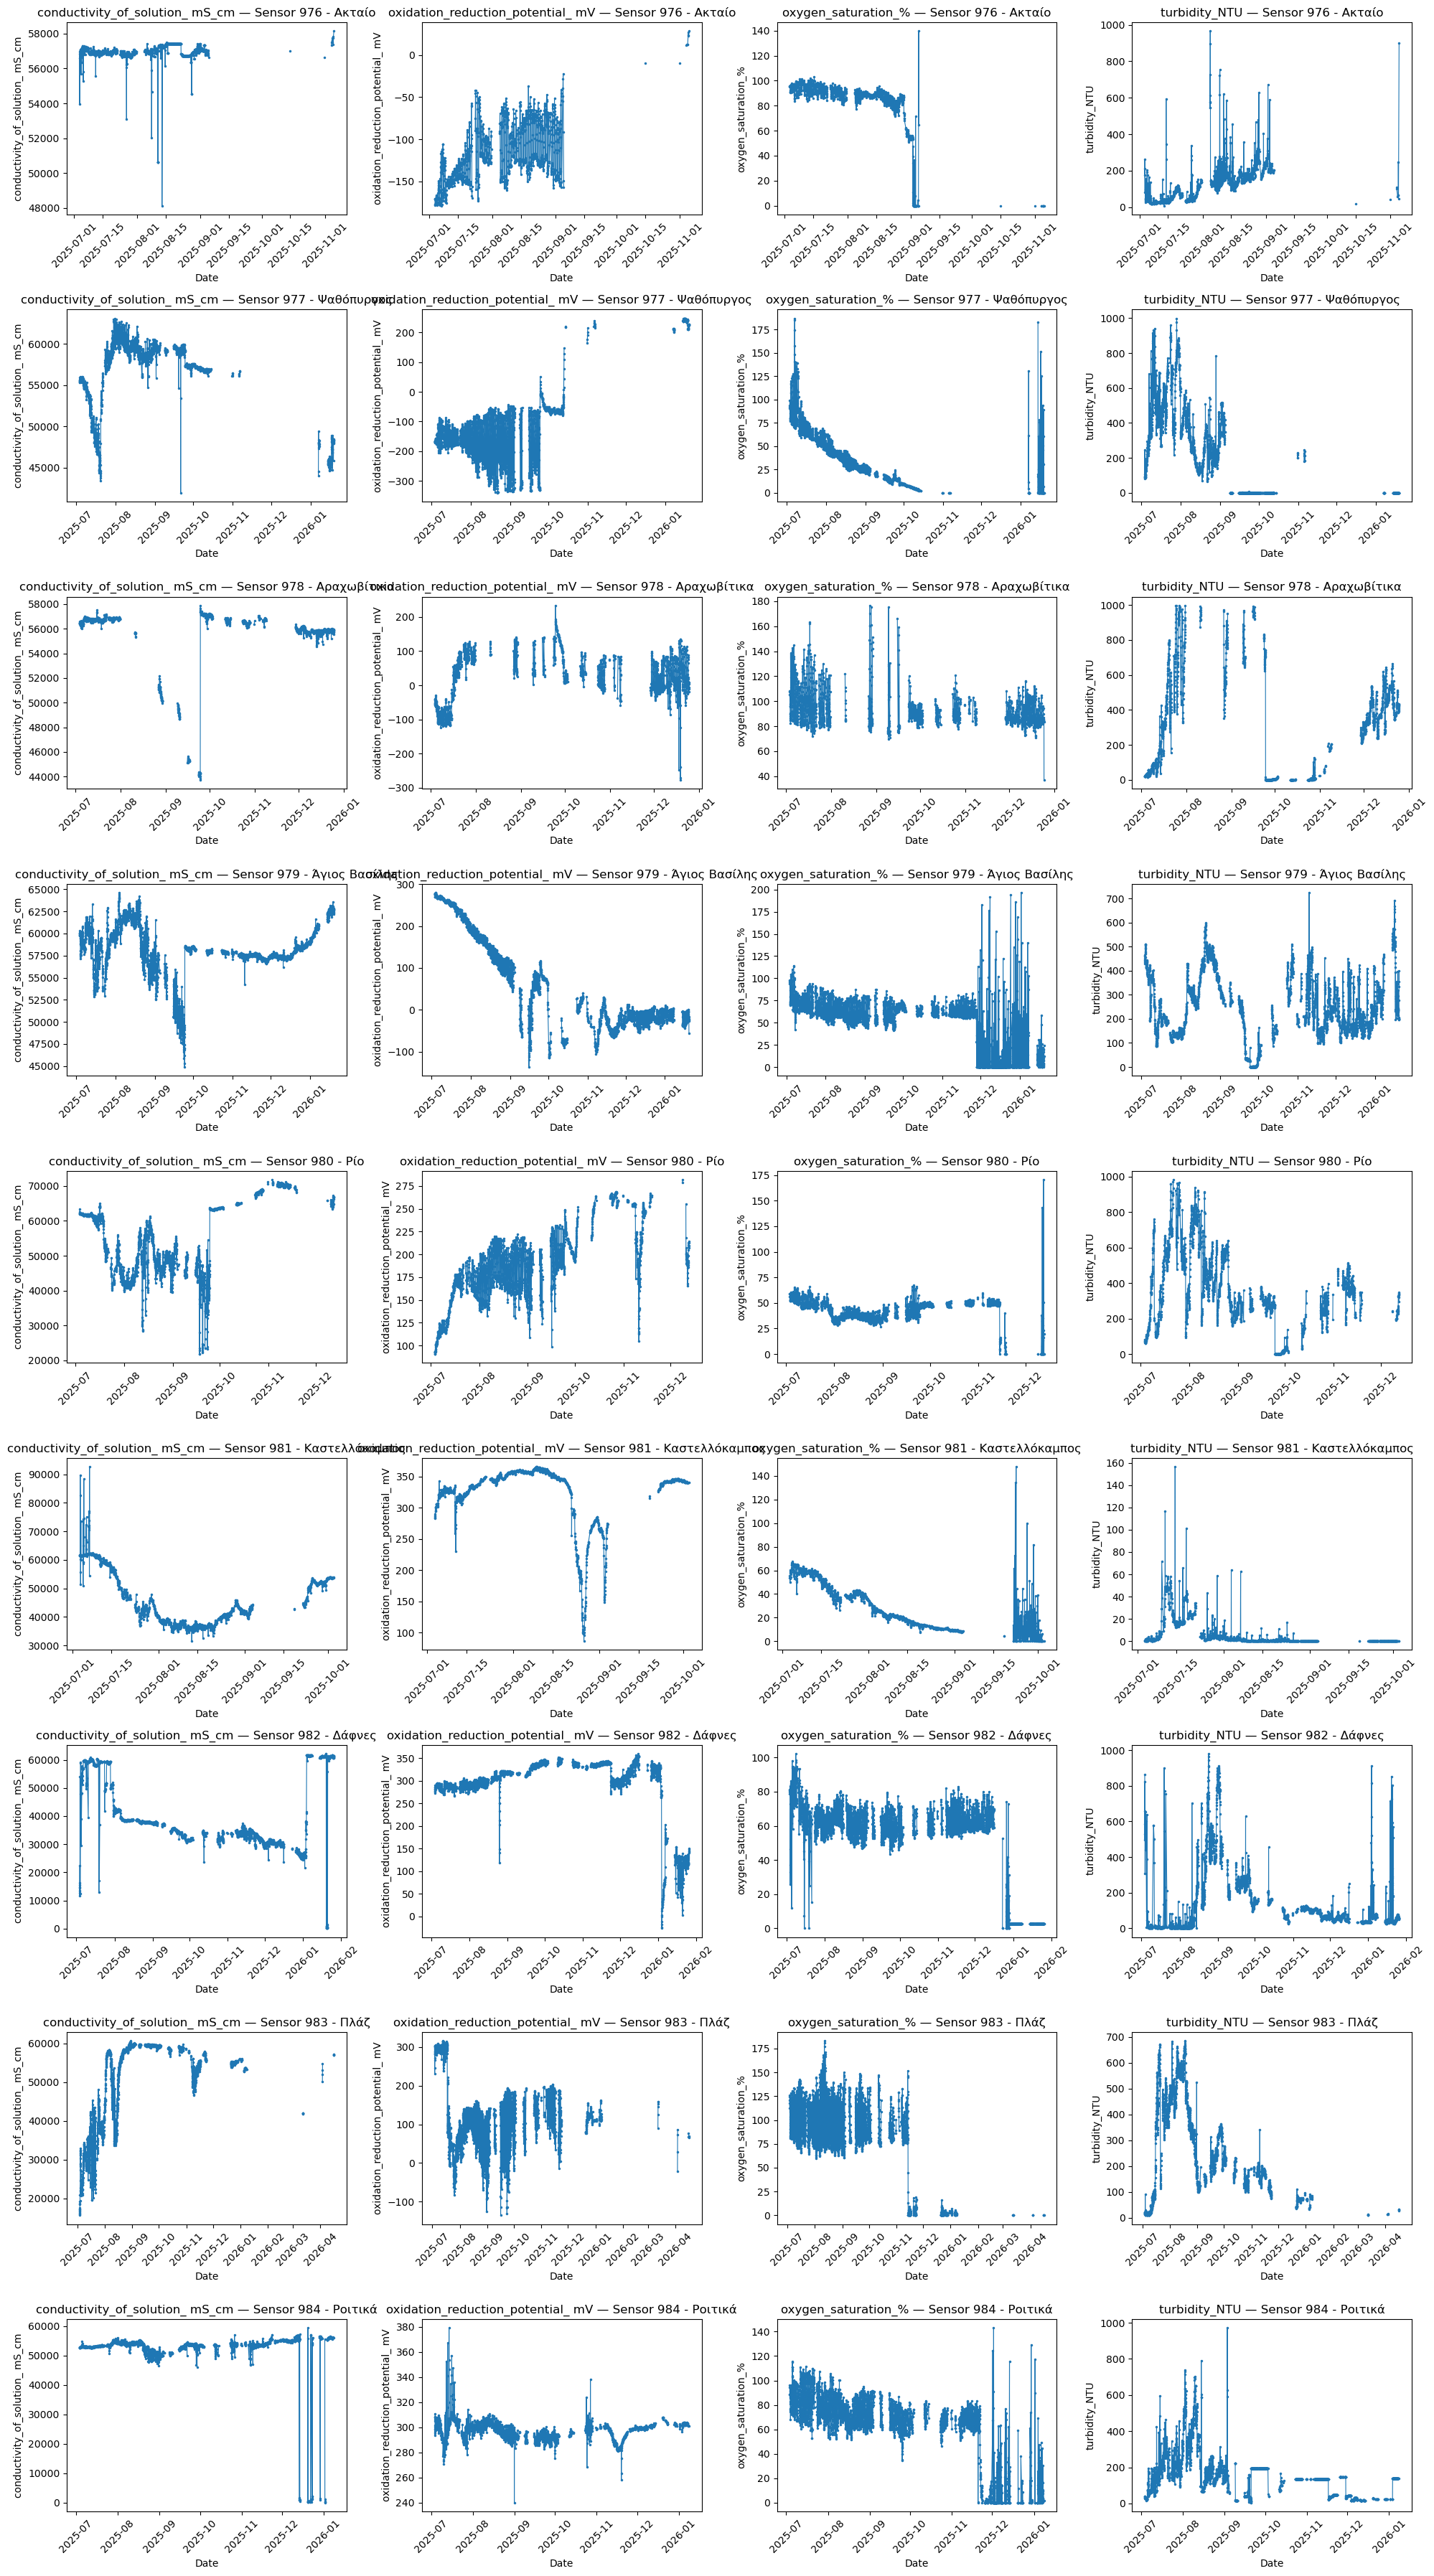

In [30]:
plot_sensors(
    sensor_ids=sorted(
        df_model[SENSOR_COL].unique()
    ),
    metrics=MODEL_FEATURES,
    data=df_model,
    max_gap="24h",
    show_points=True,
)

In [25]:
def inspect_flagged_rows(
    sensor_id=None,
    feature=None,
    maximum_rows=100,
):
    flagged = df_clean.copy()

    if sensor_id is not None:
        flagged = flagged.loc[
            flagged[SENSOR_COL] == sensor_id
        ]

    if feature is not None:
        flag_column = (
            f"{feature}__statistical_suspect"
        )

        if flag_column not in flagged.columns:
            raise KeyError(
                f"No statistical flag exists for '{feature}'."
            )

        flagged = flagged.loc[
            flagged[flag_column]
        ]
    else:
        flagged = flagged.loc[
            flagged["any_statistical_suspect"]
            | flagged["oxygen_sensor_suspect"]
        ]

    columns_to_show = [
        SENSOR_COL,
        TIME_COL,
        *MODEL_FEATURES,
        "any_statistical_suspect",
        "oxygen_sensor_suspect",
    ]

    return (
        flagged[columns_to_show]
        .sort_values([SENSOR_COL, TIME_COL])
        .head(maximum_rows)
    )


# Examples:
# display(inspect_flagged_rows(sensor_id=976))
# display(
#     inspect_flagged_rows(
#         sensor_id=981,
#         feature=TURBIDITY_COL,
#     )
# )

## 11. Optional sensitivity comparison

This summary is provided for reference. The main clustering workflow should use `df_model`.

In [26]:
comparison_summary = pd.DataFrame({
    "dataset": [
        "df_model",
        "df_model_strict",
    ],
    "rows": [
        len(df_model),
        len(df_model_strict),
    ],
    "sensors": [
        df_model[SENSOR_COL].nunique(),
        df_model_strict[SENSOR_COL].nunique(),
    ],
    "start": [
        df_model[TIME_COL].min(),
        df_model_strict[TIME_COL].min(),
    ],
    "end": [
        df_model[TIME_COL].max(),
        df_model_strict[TIME_COL].max(),
    ],
})

display(comparison_summary)

,dataset,rows,sensors,start,end
0,df_model,21161,9,2025-07-03 15:00:00,2026-04-16 06:00:00
1,df_model_strict,16256,9,2025-07-03 15:00:00,2026-04-15 21:00:00


## 12. Save outputs

Uncomment the required exports after reviewing the final audit tables.

In [31]:
# df_clean.to_csv(
#     "water_cleaned_with_audit_flags.csv",
#     index=False,
# )
#
df_model.to_csv(
    "data/water_model_ready.csv",
    index=False,
)
#
# df_model_strict.to_csv(
#     "water_model_ready_strict_sensitivity.csv",
#     index=False,
# )
#
# retention_by_sensor.to_csv(
#     "water_cleaning_retention_by_sensor.csv",
# )
#
# feature_audit.to_csv(
#     "water_cleaning_feature_audit.csv",
#     index=False,
# )

## Recommended next step

Use `df_model` as the input to the clustering notebook. Keep `df_clean` as the audit dataset because it preserves unaffected measurements and records why each invalid value was excluded.